In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast
from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [2]:
import sys
# Ensure this analysis directory is importable regardless of kernel CWD
_here = '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis'
if _here not in sys.path:
    sys.path.insert(0, _here)

import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *
from config import *

In [3]:
import importlib
import firefate.utils.plots, firefate.utils.custom
import temporal_clustering
# reload firefate helpers first, then temporal_clustering so it re-binds fresh names
importlib.reload(firefate.utils.plots)
importlib.reload(firefate.utils.custom)
importlib.reload(temporal_clustering)
from temporal_clustering import FateFrequency, TFForceWaves, WaveValidation

In [4]:
config = Config()

In [5]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file('/work/nvme/bhdw/asachan/data_files/firefate/bcell/outs/dynamic.h5')

## Cell state distributions over pseudotime (fate frequency trajectory)

In [6]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [7]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

## TF forces per branch

In [21]:
# Class 1: cell-state fate frequencies + extrema / termination pseudotimes
ff_pb = FateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 2),
)
pseudotime_values_of_windows = ff_pb.pseudotime_values_of_windows

In [ ]:
# Class 2: TF forces over pseudotime (expression / regulation curves cached internally)
waves_pb = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 2),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

### FIREFate state-specific enriched links

In [10]:
ss_firefate_links = pd.read_csv('/projects/bhdw/asachan/tmp/ss_firefate_links_2B.csv')

In [11]:
display(ss_firefate_links)

,source,target,key,weight,cluster,strength,case
0,PRDM1,RUNX2,1,0.293075,3,1,slide
1,PRDM1,IQGAP2,1,0.219831,3,1,slide
2,BACH2,XBP1,0,-0.229950,7,1,slide
3,BACH2,MZB1,1,-0.234813,3,1,slide
4,BACH2,JCHAIN,1,-0.258168,3,1,slide
...,...,...,...,...,...,...,...
73,PBX3,CDK6,1,0.231756,3,1,slide
74,PBX3,AFF3,1,0.332018,3,1,slide
75,ARID5B,CPEB4,1,0.237878,3,1,slide
76,ARID5B,PDE4D,0,0.228636,7,1,slide


In [12]:
# Build (TF, target) tuples, keeping only links whose TF and target are both
# present in the dictys object. get_beta_curves can only compute forces for genes
# in the GRN (TFs in nids[0], targets in ndict); filtering here makes the computed
# link set explicit rather than relying on the internal skip.
all_links = list(zip(ss_firefate_links['source'], ss_firefate_links['target']))

_, _, missing_tfs = get_tf_indices(dictys_dynamic_object, list({tf for tf, _ in all_links}))
missing_tfs = set(missing_tfs)
ndict = dictys_dynamic_object.ndict

ss_firefate_tuple = [(tf, tg) for tf, tg in all_links
                     if tf not in missing_tfs and tg in ndict]
dropped = [(tf, tg) for tf, tg in all_links
           if tf in missing_tfs or tg not in ndict]
print(f"{len(ss_firefate_tuple)}/{len(all_links)} links kept; "
      f"{len(dropped)} dropped (TF/target absent from GRN): {dropped}")

66/78 links kept; 12 dropped (TF/target absent from GRN): [('AFF1', 'MAN1A1'), ('AFF1', 'FNDC3A'), ('AFF1', 'CEP128'), ('HERPUD1', 'TRAM1'), ('HERPUD1', 'IRF4'), ('HERPUD1', 'BTG2'), ('HERPUD1', 'PAX5'), ('HIVEP2', 'IRF4'), ('HIVEP2', 'BTG2'), ('HIVEP2', 'GAB1'), ('HIVEP2', 'GLCCI1'), ('HIVEP2', 'CPEB4')]


In [13]:
display(ss_firefate_tuple[:5])

[('PRDM1', 'RUNX2'),
 ('PRDM1', 'IQGAP2'),
 ('BACH2', 'XBP1'),
 ('BACH2', 'MZB1'),
 ('BACH2', 'JCHAIN')]

In [14]:
# Compute beta / TF-expression / force curves for the prioritized links
force_curves = waves.compute_forces(ss_firefate_tuple, varname='w_in')
dtime = waves.dtime

In [15]:
display(waves.beta_curves.head())

time_0    time_1    time_2    time_3    time_4    time_5  \
TF    Target                                                               
TCF12 GAB1    0.021352  0.022571  0.023825  0.025107  0.026414  0.027738   
      FNDC3A -0.002854 -0.003855 -0.004898 -0.005973 -0.007074 -0.008189   
      RNF213 -0.001684 -0.001719 -0.001760 -0.001807 -0.001864 -0.001931   
      MZB1   -0.012614 -0.012885 -0.013154 -0.013423 -0.013691 -0.013958   
      IRF4    0.024027  0.023986  0.023862  0.023658  0.023375  0.023016   

                time_6    time_7    time_8    time_9  ...   time_90   time_91  \
TF    Target                                          ...                       
TCF12 GAB1    0.029074  0.030414  0.031751  0.033077  ...  0.058476  0.059172   
      FNDC3A -0.009310 -0.010427 -0.011529 -0.012606  ... -0.107367 -0.110101   
      RNF213 -0.002011 -0.002105 -0.002213 -0.002336  ... -0.026808 -0.025869   
      MZB1   -0.014225 -0.014493 -0.014760 -0.015028  ...  0.017959  0.017844   
      IRF4    0.022586  0.022090  0.021536  0.020929  ...  0.015105  0.019312   

               time_92   time_93   time_94   time_95   time_96   time_97  \
TF    Target                                                               
TCF12 GAB1    0.059793  0.060335  0.060796  0.061173  0.061463  0.061667   
      FNDC3A -0.112670 -0.115061 -0.117266 -0.119275 -0.121083 -0.122684   
      RNF213 -0.024858 -0.023784 -0.022657 -0.021487 -0.020284 -0.019057   
      MZB1    0.017724  0.017602  0.017478  0.017353  0.017226  0.017099   
      IRF4    0.023689  0.028219  0.032884  0.037664  0.042541  0.047496   

               time_98   time_99  
TF    Target                      
TCF12 GAB1    0.061782  0.061809  
      FNDC3A -0.124073 -0.125249  
      RNF213 -0.017816 -0.016569  
      MZB1    0.016971  0.016843  
      IRF4    0.052512  0.057572  

[5 rows x 100 columns]

In [19]:
display(len(waves.force_curves))

408

In [16]:
display(waves.force_curves.head())

time_0    time_1    time_2    time_3    time_4    time_5  \
TF    Target                                                               
TCF12 GAB1    0.489438  0.501599  0.513710  0.525727  0.537607  0.549306   
      FNDC3A -0.204247 -0.232831 -0.258430 -0.281802 -0.303369 -0.323381   
      RNF213 -0.162419 -0.163954 -0.165681 -0.167671 -0.169987 -0.172679   
      MZB1   -0.389426 -0.393198 -0.396902 -0.400543 -0.404124 -0.407650   
      IRF4    0.515187  0.515014  0.514062  0.512327  0.509816  0.506545   

                time_6    time_7    time_8    time_9  ...   time_90   time_91  \
TF    Target                                          ...                       
TCF12 GAB1    0.560780  0.571985  0.582882  0.593433  ...  0.765165  0.769192   
      FNDC3A -0.341995 -0.359314 -0.375406 -0.390319  ... -0.996236 -1.007287   
      RNF213 -0.175785 -0.179325 -0.183304 -0.187710  ... -0.545322 -0.537004   
      MZB1   -0.411123 -0.414550 -0.417934 -0.421281  ...  0.458244  0.457011   
      IRF4    0.502537  0.497825  0.492447  0.486448  ...  0.425065  0.472974   

               time_92   time_93   time_94   time_95   time_96   time_97  \
TF    Target                                                               
TCF12 GAB1    0.772776  0.775904  0.778567  0.780757  0.782469  0.783697   
      FNDC3A -1.017542 -1.026987 -1.035615 -1.043418 -1.050394 -1.056543   
      RNF213 -0.527845 -0.517880 -0.507140 -0.495660 -0.483471 -0.470608   
      MZB1    0.455734  0.454423  0.453085  0.451726  0.450349  0.448959   
      IRF4    0.516919  0.557802  0.596191  0.632468  0.666900  0.699683   

               time_98   time_99  
TF    Target                      
TCF12 GAB1    0.784440  0.784697  
      FNDC3A -1.061867 -1.066372  
      RNF213 -0.457101 -0.442982  
      MZB1    0.447558  0.446148  
      IRF4    0.730966  0.760864  

[5 rows x 100 columns]

## Link validation

In [17]:
# Validate enriched links vs size-matched random links.
# Random pool is "non-enriched" per `exclude`:
#   'tf_and_target' -> drop every enriched TF and every enriched target (no random
#                      link shares any TF/target with the enriched set; strictest null)
#   'links'         -> keep the full universe, drop only the exact enriched (TF, Target)
#                      pairs (a random link may reuse one of our TFs/targets elsewhere)
# Within each wave a random subset is drawn to match the number of enriched links.
# Switch boundaries are the same termination pseudotimes used for the wave assignment.
switch_pseudotimes = [
    ff.termination_pseudotime(state, PB_post_bifurcation_window_indices, method='threshold')
    for state in ['ActB-4', 'earlyPB']
]

validation = WaveValidation(
    waves,
    enriched_links=ss_firefate_tuple,
    switch_pseudotimes=switch_pseudotimes,
    varname='w_in',
)

,link,wave,group,abs_max_force
0,"(ARID5B, PDE4D)",1,enriched,0.210999
1,"(ARID5B, PIKFYVE)",1,enriched,0.222184
2,"(BACH2, XBP1)",1,enriched,0.282425
3,"(BATF, CDK6)",1,enriched,0.276482
4,"(CREB3L2, FNDC3A)",1,enriched,0.806713
...,...,...,...,...
127,"(ZNF18, SSR4)",3,random,0.212744
128,"(ZNF519, ACBD3)",3,random,0.569728
129,"(ZNF519, ANGPT2)",3,random,0.650472
130,"(TCFL5, IL15RA)",3,random,0.396117


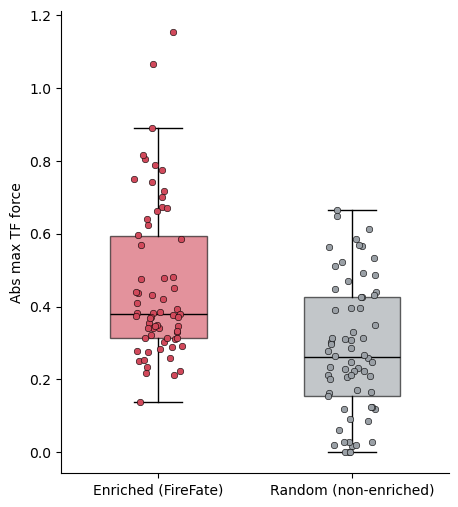

In [20]:
val_df = validation.run(n_tf=12, n_target=34, exclude='tf_and_target', random_state=0)
display(val_df)

# pooled (whole-trajectory) comparison: enriched vs random across all waves
fig, ax = validation.plot_overall(ylabel='Abs max TF force')
plt.show()

## Wave assignment by cell-state termination pseudotimes

In [ ]:
# PB -> 3 waves: switch boundaries are the termination pseudotimes of ActB-4 then earlyPB.
# A link lands in wave 1 if its softmax peak <= ActB-4 termination, wave 2 if between the
# two terminations, wave 3 if after earlyPB termination.
for state in ['ActB-4', 'earlyPB']:
    print(state, 'termination pseudotime:',
          ff.termination_pseudotime(state, PB_post_bifurcation_window_indices, method='threshold'))

pb_wave_assignments = waves.classify_waves_from_states(
    ff,
    PB_post_bifurcation_window_indices,
    boundary_states=['ActB-4', 'earlyPB'],
    termination_method='threshold',
    threshold_frac=0.1,
)
display(pb_wave_assignments)

In [ ]:
# subset pb_wave_assignments to just the enriched links
mask = pb_wave_assignments[['TF', 'Target']].apply(tuple, axis=1).isin(PB_links_plotting)
enriched_waves = pb_wave_assignments[mask].copy()
enriched_waves['link'] = list(zip(enriched_waves['TF'], enriched_waves['Target']))
enriched_waves = enriched_waves[['link', 'wave']].sort_values('wave').reset_index(drop=True)

display(enriched_waves)

## Wave-clustered FireFate links vs random links

In [ ]:
# Per-wave comparison: enriched vs size-matched random links, one group of boxes per wave.
# Each point is one link's abs max TF force (max_t |force(t)|). Reuses the run() above.
fig, ax = validation.plot(ylabel='Abs max TF force')
# fig.savefig(os.path.join(config.OUTPUT_FOLDER, 'wave_validation_PB.pdf'), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# GC fate -> 2 waves: single switch boundary at the termination pseudotime of ActB-3.
# (compute GC forces first, then classify against the GC post-bifurcation windows)
# gc_force_curves = waves.compute_forces(GC_links_plotting, varname='w_in')
# gc_wave_assignments = waves.classify_waves_from_states(
#     ff,
#     GC_post_bifurcation_window_indices,
#     boundary_states=['ActB-3'],
#     termination_method='threshold',
#     threshold_frac=0.1,
# )
# display(gc_wave_assignments)